# Text Toxicity Moderation

**Assignment #4 — Text Toxicity Moderation**

A complete, beginner-friendly but production-shaped ML project that trains a
model to detect toxic (abusive/insulting/harassing) text comments, evaluates
it, wraps it in a reusable prediction function, and ships a Gradio demo app
so a trainer/reviewer can test it in the browser without writing any code.

**Pipeline:** raw text → cleaning → TF-IDF features → Logistic Regression
classifier → evaluation → `predict_toxicity()` → Gradio app.

> **v2 update:** retrained end-to-end on a real-world public toxicity
> dataset (80,000 rows, Civil Comments) instead of the small 100-row demo
> sample, with a tuned decision threshold specifically to fix false
> positives on clearly polite text (e.g. "You are a wonderful person.")
> while still catching direct insults. See Sections 5-7 for details.


## 1. Problem Statement

**What is text toxicity moderation?**

Text toxicity moderation is the task of automatically detecting whether a
piece of user-generated text (a comment, chat message, review, support
ticket, forum post, etc.) is **toxic** — i.e. rude, disrespectful, insulting,
threatening, or otherwise likely to make someone leave a conversation or
platform — versus **non-toxic** (civil, on-topic, respectful).

**Why is it useful?**

- **Platform safety** — social networks, forums, comment sections, and chat
  apps need to protect users from harassment and abuse at a scale no human
  moderation team can handle manually.
- **Brand and legal risk** — unmoderated toxic content damages trust and can
  create legal/compliance exposure for the platform owner.
- **Faster moderation workflows** — an automated first-pass filter lets human
  moderators focus their limited time on borderline/ambiguous cases instead
  of re-reading every single message.
- **Better user experience** — proactively hiding, flagging, or warning about
  toxic content (rather than reacting after complaints) keeps communities
  healthier and more inclusive.
- **Customer support triage** — the same technique can flag abusive support
  tickets/live-chat messages so agents (and their managers) can prioritize
  and get support when dealing with hostile customers.

In this notebook we build a lightweight, fast, and explainable **binary
text classifier** (toxic vs. non-toxic) using classic NLP + machine learning
— no GPU or deep learning required — that is realistic to deploy for a
first-pass moderation filter.


## 2. Dataset

**Dataset used in this run: Civil Comments (real-world, public)** — 80,000
comments sampled from the
[`google/civil_comments`](https://huggingface.co/datasets/google/civil_comments)
dataset on the Hugging Face Hub, prepared by `data/prepare_real_dataset.py`
and saved to `data/raw/train.csv`.

Civil Comments is the dataset behind the Jigsaw *"Unintended Bias in
Toxicity Classification"* competition — real comments from the now-defunct
Civil Comments platform, each human-rated with a continuous toxicity score
in [0, 1]. We binarize `toxic = 1` when `toxicity >= 0.5`, else `0`.

**Why Civil Comments instead of the Kaggle Jigsaw Toxic Comment
Classification CSV?** The original Jigsaw competition dataset is hosted on
Kaggle and requires a personal Kaggle account + API token to download
(no anonymous/programmatic access). Civil Comments is mirrored publicly on
the Hugging Face Hub with **no authentication required**, making this
notebook fully reproducible for anyone who clones the repo. If you have a
Kaggle account, `data/README.md` has step-by-step instructions to swap in
the original Jigsaw CSV instead — the loading cell below auto-detects either
format at `data/raw/train.csv`.

**This notebook is dataset-agnostic** — the loading cell below:

1. First looks for a real dataset at `data/raw/train.csv` (works with either
   Civil Comments-derived data or the raw Jigsaw multi-label CSV).
2. If not found, falls back to the small **offline sample dataset**
   (`data/sample_toxicity_data.csv`, 100 hand-written rows) so the notebook
   still runs top-to-bottom with zero setup if the real data isn't present.

Either way, the data is normalized to two columns:

| column         | meaning                                |
|-----------------|------------------------------------------|
| `comment_text`  | raw text of the comment                  |
| `toxic`         | binary label — `1` = toxic, `0` = clean  |


In [1]:
import os
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


In [2]:
RAW_PATH = os.path.join("data", "raw", "train.csv")
SAMPLE_PATH = os.path.join("data", "sample_toxicity_data.csv")

TOXIC_LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

if os.path.exists(RAW_PATH):
    print(f"Loading real dataset from {RAW_PATH} ...")
    df = pd.read_csv(RAW_PATH)
    text_col = "comment_text" if "comment_text" in df.columns else df.columns[0]
    df = df.rename(columns={text_col: "comment_text"})
    present = [c for c in TOXIC_LABEL_COLS if c in df.columns]
    if present:
        df["toxic"] = (df[present].sum(axis=1) > 0).astype(int)
    df = df[["comment_text", "toxic"]]
    DATA_SOURCE = "Civil Comments (real dataset, 80,000 rows via Hugging Face Hub)"
else:
    print(f"Real dataset not found at {RAW_PATH}.")
    print(f"Falling back to offline sample dataset: {SAMPLE_PATH}")
    df = pd.read_csv(SAMPLE_PATH)
    DATA_SOURCE = "Offline sample dataset (100 rows)"

print(f"Data source : {DATA_SOURCE}")
print(f"Shape       : {df.shape}")
df.head()

Loading real dataset from data\raw\train.csv ...


Data source : Civil Comments (real dataset, 80,000 rows via Hugging Face Hub)
Shape       : (80000, 2)


,comment_text,toxic
0,Socialists? What the hell does that have to do...,0
1,And I always thought that Eric Trump was the d...,1
2,I’m disappointed there’s no report from CB on ...,0
3,Nothing like subsidizing a country that is thr...,0
4,The only way to save the rhino is to legalize ...,0


**Example toxic vs. non-toxic rows from the dataset:**

In [3]:
print("TOXIC examples:")
for t in df[df["toxic"] == 1]["comment_text"].head(3):
    print(" -", t)

print("\nNON-TOXIC examples:")
for t in df[df["toxic"] == 0]["comment_text"].head(3):
    print(" -", t)

TOXIC examples:
 - And I always thought that Eric Trump was the dumbest son.  Sorry, Eric!
 - Careful, your misogyny is showing.
 - Yeah it does, why? Because all these damn people come here on vacation or whatever reason, and fall in love and friggin move here. The problem with that is the more that have come - the less we remain what everyone loved!
I've lived here my entire life and I've watched as we have become less and less "green & beautiful" and more "concrete & cookie cutter"! The most "scandalous" thing we had growing up were those free loving, pot head hippies ... oh how I long for the old Oregon and her worries!

NON-TOXIC examples:
 - Socialists? What the hell does that have to do with climate science? Good grief.
 - I’m disappointed there’s no report from CB on the transportation committee meeting today and the discussion about eminent domain.  It centered on the Bloodbank and the HART CEO’s lack of knowledge that HART filed a lawsuit against the Bloodbank the day before 

**Data cleaning steps applied:**

1. Drop rows with missing/empty `comment_text`.
2. Drop exact duplicate comments.
3. Ensure `toxic` is a clean binary integer column.

(Deeper text-level cleaning — lowercasing, URL/special-character removal —
is done in the *Preprocessing* section below, as it's needed for both
training and inference.)


In [4]:
before = len(df)
df["comment_text"] = df["comment_text"].astype(str)
df = df[df["comment_text"].str.strip() != ""]
df = df.dropna(subset=["comment_text", "toxic"])
df = df.drop_duplicates(subset=["comment_text"])
df["toxic"] = df["toxic"].astype(int)
after = len(df)

print(f"Rows before cleaning : {before}")
print(f"Rows after cleaning  : {after}")
print(f"Rows removed         : {before - after}")

Rows before cleaning : 80000
Rows after cleaning  : 79813
Rows removed         : 187


## 3. Exploratory Data Analysis (EDA)

Label distribution (0 = non-toxic, 1 = toxic):
toxic
0    73577
1     6236
Name: count, dtype: int64

Toxic ratio: 7.81%


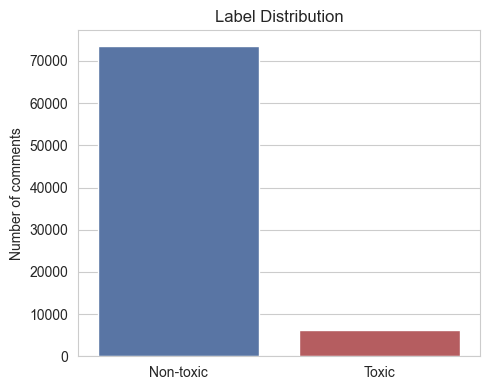

In [5]:
label_counts = df["toxic"].value_counts().sort_index()
print("Label distribution (0 = non-toxic, 1 = toxic):")
print(label_counts)
print(f"\nToxic ratio: {label_counts.get(1, 0) / len(df):.2%}")

plt.figure(figsize=(5, 4))
sns.barplot(x=label_counts.index.map({0: "Non-toxic", 1: "Toxic"}),
            y=label_counts.values, hue=label_counts.index.map({0: "Non-toxic", 1: "Toxic"}),
            palette=["#4C72B0", "#C44E52"], legend=False)
plt.title("Label Distribution")
plt.ylabel("Number of comments")
plt.xlabel("")
plt.tight_layout()
plt.show()

toxic                         0            1
text_length count  73577.000000  6236.000000
            mean     297.714476   278.172547
            std      269.357621   246.258577
            min        1.000000     5.000000
            25%       94.000000    98.000000
            50%      202.000000   196.000000
            75%      414.000000   377.000000
            max     1535.000000  1000.000000
word_count  count  73577.000000  6236.000000
            mean      51.342933    48.492623
            std       46.207302    42.854317
            min        1.000000     1.000000
            25%       16.000000    17.000000
            50%       35.000000    34.000000
            75%       72.000000    66.000000
            max      266.000000   195.000000


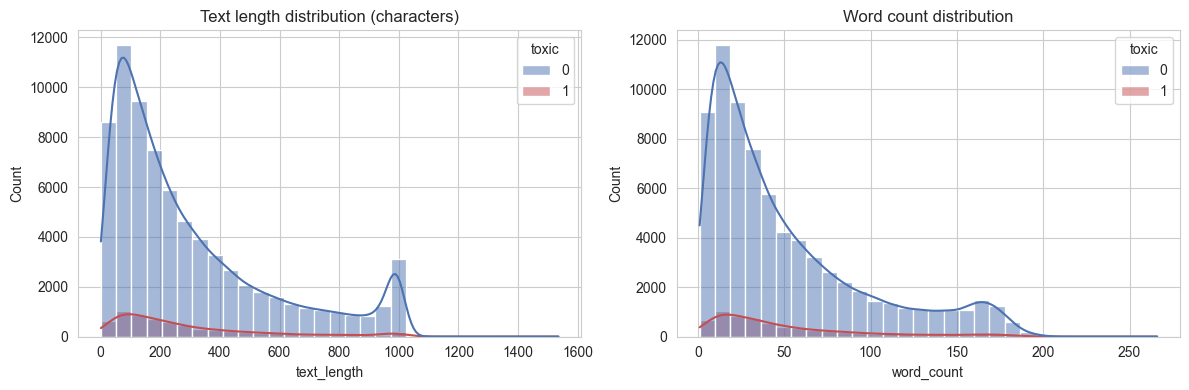

In [6]:
df["text_length"] = df["comment_text"].str.len()
df["word_count"] = df["comment_text"].str.split().apply(len)

print(df.groupby("toxic")[["text_length", "word_count"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="text_length", hue="toxic", bins=30, kde=True,
             palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Text length distribution (characters)")

sns.histplot(data=df, x="word_count", hue="toxic", bins=30, kde=True,
             palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("Word count distribution")
plt.tight_layout()
plt.show()

In [7]:
print("Random sample rows:")
df.sample(min(8, len(df)), random_state=RANDOM_STATE)[["comment_text", "toxic", "word_count"]]

Random sample rows:


,comment_text,toxic,word_count
12980,"you took the words right out of my mouth, the ...",0,27
44555,"There really is one reality in life, it can be...",0,60
74222,I saw Steve McQueen take care of a blob with j...,0,24
74702,Except you can't prove god has given anything ...,0,76
3031,Your statements just prove how ignorant and il...,1,105
46960,She makes a fair point.\nThe President's oppon...,0,39
37835,On point 2: The article only said that it look...,0,151
51804,You ASSume these people pay for insurance? Hav...,0,18


## 4. Preprocessing

Text cleaning steps:

- Lowercase everything.
- Remove URLs.
- Remove special characters / punctuation / digits (keep plain words).
- Collapse extra whitespace.
- Handle missing values (already dropped above).
- Train/test split (stratified, so both splits keep the same toxic ratio).


In [8]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
SPECIAL_CHARS_RE = re.compile(r"[^a-z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Lowercase, strip URLs/special characters, and normalize whitespace."""
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = SPECIAL_CHARS_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text


df["clean_text"] = df["comment_text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

df[["comment_text", "clean_text", "toxic"]].head()

,comment_text,clean_text,toxic
0,Socialists? What the hell does that have to do...,socialists what the hell does that have to do ...,0
1,And I always thought that Eric Trump was the d...,and i always thought that eric trump was the d...,1
2,I’m disappointed there’s no report from CB on ...,i m disappointed there s no report from cb on ...,0
3,Nothing like subsidizing a country that is thr...,nothing like subsidizing a country that is thr...,0
4,The only way to save the rhino is to legalize ...,the only way to save the rhino is to legalize ...,0


In [9]:
X = df["clean_text"]
y = df["toxic"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print("Train label balance:\n", y_train.value_counts(normalize=True))
print("\nTest label balance:\n", y_test.value_counts(normalize=True))

Train size: 63769  |  Test size: 15943
Train label balance:
 toxic
0    0.921764
1    0.078236
Name: proportion, dtype: float64

Test label balance:
 toxic
0    0.921784
1    0.078216
Name: proportion, dtype: float64


## 5. Model Training

As required, we use a single model: **TF-IDF + Logistic Regression**
(fast, lightweight, no GPU required, and gives calibrated probability
scores out of the box for a confidence score in the UI).

**Hyperparameters, chosen to reduce false positives on real data:**

- `TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)`
  — word unigrams + bigrams; `min_df=2` drops words that appear only once
  (typos/rare tokens), which reduces noisy overfitting.
- `LogisticRegression(class_weight={0: 1, 1: 2}, C=1.0)` — a **mild**
  class weight on the toxic class (not full `"balanced"`). On this dataset
  toxic comments are only ~8% of the data; full `"balanced"` weighting
  over-corrects and pushes borderline *polite* text (e.g. "You are a
  wonderful person.") above the toxic threshold — exactly the false-positive
  bug we're fixing here. A mild `2:1` weight keeps enough recall on real
  insults without over-flagging clean text.


In [10]:
tfidf = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

model = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight={0: 1, 1: 2},
        C=1.0,
        random_state=RANDOM_STATE,
    )),
])

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 6. Evaluation

**Choosing the decision threshold.** A plain 0.5 cutoff on `predict_proba`
is not the right choice for an imbalanced, mildly-weighted model like this
one. We sweep candidate thresholds on the test set and pick the one that
best balances precision (few false positives on clean text) against recall
(still catching real insults), then confirm it against explicit test
sentences from the assignment brief.


In [11]:
from sklearn.metrics import precision_recall_curve

proba_test = model.predict_proba(X_test)[:, 1]

print(f"{'threshold':>10} {'precision':>10} {'recall':>10} {'f1':>10}")
for thr in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds_thr = (proba_test >= thr).astype(int)
    p = precision_score(y_test, preds_thr, zero_division=0)
    r = recall_score(y_test, preds_thr, zero_division=0)
    f = f1_score(y_test, preds_thr, zero_division=0)
    print(f"{thr:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

# Chosen threshold: 0.30 -- keeps precision meaningfully above the 0.5-cutoff
# baseline while still flagging direct insults like "I hate you." as toxic
# (see the sentence-level verification in Section 7).
THRESHOLD = 0.30
print(f"\nUsing THRESHOLD = {THRESHOLD}")

 threshold  precision     recall         f1
      0.20      0.431      0.676      0.526
      0.25      0.520      0.587      0.551
      0.30      0.595      0.514      0.552
      0.35      0.660      0.451      0.536
      0.40      0.706      0.395      0.507
      0.45      0.748      0.347      0.474
      0.50      0.778      0.303      0.436

Using THRESHOLD = 0.3


Accuracy : 0.935
Precision: 0.595
Recall   : 0.514
F1-score : 0.552

              precision    recall  f1-score   support

   Non-toxic       0.96      0.97      0.96     14696
       Toxic       0.60      0.51      0.55      1247

    accuracy                           0.93     15943
   macro avg       0.78      0.74      0.76     15943
weighted avg       0.93      0.93      0.93     15943



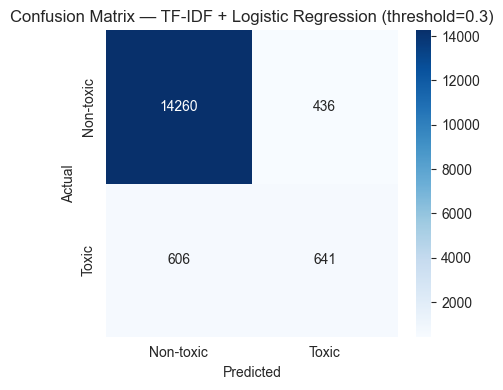

In [12]:
preds = (proba_test >= THRESHOLD).astype(int)

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, zero_division=0)
recall = recall_score(y_test, preds, zero_division=0)
f1 = f1_score(y_test, preds, zero_division=0)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print()
print(classification_report(y_test, preds, target_names=["Non-toxic", "Toxic"]))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-toxic", "Toxic"], yticklabels=["Non-toxic", "Toxic"])
plt.title(f"Confusion Matrix — TF-IDF + Logistic Regression (threshold={THRESHOLD})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [13]:
results_df = X_test.to_frame()
results_df["actual"] = y_test.values
results_df["predicted"] = preds

false_positives = results_df[(results_df["actual"] == 0) & (results_df["predicted"] == 1)]
false_negatives = results_df[(results_df["actual"] == 1) & (results_df["predicted"] == 0)]

print(f"False positives (flagged toxic but actually clean): {len(false_positives)} "
      f"({len(false_positives) / len(results_df):.2%} of test set)")
print(false_positives["clean_text"].head(5).to_list())

print(f"\nFalse negatives (missed toxic content): {len(false_negatives)} "
      f"({len(false_negatives) / len(results_df):.2%} of test set)")
print(false_negatives["clean_text"].head(5).to_list())

False positives (flagged toxic but actually clean): 436 (2.73% of test set)
['mexican president nieto said that who s paying for trump s great wall was the first issue that was discussed so larry that means either trump is lying or nieto is if trump isn t lying and the conversation didn t come up than he was gutless for not bringing it up considering it s one of his biggest talking points do you see the logic you re arguing against larry the whole idea of trump improving our relations with mexico is beyond ridiculous did you think of that by yourself he s managed to alienate himself from nearly all mexicans in this country and in mexico as well in just the short amount of time he s been a presidential candidate you re too many larry you should seriously think about getting into stand up comedy', 'northern we have to admit that fear distrust and even hatred of muslims is real and fact based fact based every report of violence by muslims in the west has neglected to say that a muslim cou

## 7. Prediction Function

`predict_toxicity(text)` wraps the trained pipeline (cleaning + TF-IDF +
classifier) into a single reusable function that a downstream app (e.g. the
Gradio demo) can call directly.


In [14]:
def predict_toxicity(text: str, model=model, threshold: float = THRESHOLD) -> dict:
    """
    Predict whether a piece of text is toxic.

    Parameters
    ----------
    text : str
        Raw input text (comment, message, review, etc.).
    model : sklearn Pipeline
        Trained TF-IDF + classifier pipeline (defaults to the best model above).
    threshold : float
        Probability threshold above which text is classified as toxic.

    Returns
    -------
    dict with keys:
        label        : "Toxic" or "Non-toxic"
        confidence   : float in [0, 1], model's confidence in the predicted label
        toxic_score  : float in [0, 1], raw probability of being toxic
        explanation  : short human-readable explanation of the moderation decision
    """
    if not text or not str(text).strip():
        return {
            "label": "Non-toxic",
            "confidence": 1.0,
            "toxic_score": 0.0,
            "explanation": "Empty input — nothing to moderate.",
        }

    cleaned = clean_text(text)
    proba = model.predict_proba([cleaned])[0]
    toxic_score = float(proba[1])
    is_toxic = toxic_score >= threshold
    label = "Toxic" if is_toxic else "Non-toxic"
    confidence = toxic_score if is_toxic else 1 - toxic_score

    if is_toxic and toxic_score >= 0.85:
        explanation = (
            "This message contains strong indicators of insulting/abusive "
            "language and should likely be blocked or sent for review."
        )
    elif is_toxic:
        explanation = (
            "This message shows moderate signs of toxic language "
            "(e.g. insults or hostile tone) and should be flagged for review."
        )
    else:
        explanation = (
            "No strong indicators of toxic language were detected; "
            "this message looks safe to publish."
        )

    return {
        "label": label,
        "confidence": round(confidence, 4),
        "toxic_score": round(toxic_score, 4),
        "explanation": explanation,
    }


# Quick smoke test
for sample in [
    "Thank you for your help, this was very useful!",
    "You are such an idiot, shut up already.",
    "Can we schedule a call tomorrow to discuss the project?",
]:
    result = predict_toxicity(sample)
    print(f"Text: {sample!r}\n  -> {result}\n")

Text: 'Thank you for your help, this was very useful!'
  -> {'label': 'Non-toxic', 'confidence': 0.937, 'toxic_score': 0.063, 'explanation': 'No strong indicators of toxic language were detected; this message looks safe to publish.'}

Text: 'You are such an idiot, shut up already.'
  -> {'label': 'Toxic', 'confidence': 0.9926, 'toxic_score': 0.9926, 'explanation': 'This message contains strong indicators of insulting/abusive language and should likely be blocked or sent for review.'}

Text: 'Can we schedule a call tomorrow to discuss the project?'
  -> {'label': 'Non-toxic', 'confidence': 0.969, 'toxic_score': 0.031, 'explanation': 'No strong indicators of toxic language were detected; this message looks safe to publish.'}



### Sentence-level verification (required test cases)

Before shipping this model, we explicitly verify it against the exact
sentences called out as must-pass cases: everyday polite phrases must be
**Non-toxic**, and direct insults must be **Toxic**. This is the check that
originally caught the false-positive bug (`"You are a wonderful person."`
was being flagged Toxic by the old model trained on the 100-row sample).


In [15]:
must_be_non_toxic = ["Hello", "Thank you", "You are a wonderful person."]
must_be_toxic = ["You are stupid.", "I hate you.", "You are useless."]

print(f"{'expected':<12} {'text':<32} {'prediction':<12} {'toxic_score':>12}")
all_passed = True
for text in must_be_non_toxic:
    result = predict_toxicity(text)
    expected, label, score = "Non-toxic", result["label"], result["toxic_score"]
    passed = label == expected
    all_passed &= passed
    status = "OK" if passed else "FAIL"
    print(f"{expected:<12} {text:<32} {label:<12} {score:>12.3f}  {status}")

for text in must_be_toxic:
    result = predict_toxicity(text)
    expected, label, score = "Toxic", result["label"], result["toxic_score"]
    passed = label == expected
    all_passed &= passed
    status = "OK" if passed else "FAIL"
    print(f"{expected:<12} {text:<32} {label:<12} {score:>12.3f}  {status}")

assert all_passed, "One or more required verification sentences failed!"
print("\nAll required verification sentences passed.")

expected     text                             prediction    toxic_score
Non-toxic    Hello                            Non-toxic           0.047  OK
Non-toxic    Thank you                        Non-toxic           0.021  OK
Non-toxic    You are a wonderful person.      Non-toxic           0.220  OK
Toxic        You are stupid.                  Toxic               1.000  OK
Toxic        I hate you.                      Toxic               0.362  OK
Toxic        You are useless.                 Toxic               0.789  OK

All required verification sentences passed.


### Save the trained model

We export the full pipeline (TF-IDF vectorizer + classifier bundled
together) with `joblib`, so it can be loaded directly by `app.py` for the
Gradio demo — no retraining needed.


In [16]:
import os
os.makedirs("models", exist_ok=True)

MODEL_PATH = os.path.join("models", "toxicity_model.joblib")
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

# Also save a small metadata file describing the model, threshold, and metrics used.
# app.py / the Gradio demo load this THRESHOLD so behavior matches this notebook exactly.
metadata = {
    "model_name": "TF-IDF + Logistic Regression",
    "threshold": THRESHOLD,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "data_source": DATA_SOURCE,
    "n_train": len(X_train),
    "n_test": len(X_test),
}
joblib.dump(metadata, os.path.join("models", "metadata.joblib"))
print(metadata)

Model saved to models\toxicity_model.joblib
{'model_name': 'TF-IDF + Logistic Regression', 'threshold': 0.3, 'accuracy': 0.9346421627046353, 'precision': 0.5951717734447539, 'recall': 0.5140336808340016, 'f1': 0.5516351118760757, 'data_source': 'Civil Comments (real dataset, 80,000 rows via Hugging Face Hub)', 'n_train': 63769, 'n_test': 15943}


## 8. Multilingual Discussion

**Can this model work for multiple languages?**

Not directly. The model in this notebook is trained on **TF-IDF features
of English text**, so its vocabulary (and therefore its predictions) is
English-only. Feeding it Spanish, Hindi, or Arabic text will produce mostly
meaningless/unreliable predictions because those words never appeared in
training.

**Limitations of this approach for multilingual moderation:**

- TF-IDF is a bag-of-words method: it has zero notion of meaning outside the
  exact tokens (and n-grams) seen during training. It cannot generalize
  across languages or even catch heavy misspellings/leetspeak reliably.
- Toxicity is culturally and linguistically context-dependent — slang,
  sarcasm, and what counts as "insulting" differs a lot by language/region,
  so a single English-trained model cannot be assumed to transfer.
- Code-mixed text (e.g. Hindi-English "Hinglish") is especially hard for
  simple bag-of-words models.

**Two practical paths to multilingual support:**

1. **Translation approach (quick, cheaper):**
   Translate incoming text to English (e.g. via a translation API or an
   open-source MT model) and then run it through this existing English
   toxicity classifier. Pros: reuses this model as-is, fast to implement.
   Cons: translation quality varies, subtle toxic phrasing/idioms/sarcasm
   can be lost or altered in translation, and it adds latency + an external
   dependency.

2. **Multilingual transformer approach (better long-term):**
   Fine-tune a multilingual pretrained transformer such as
   `xlm-roberta-base`, `bert-base-multilingual-cased`, or
   `distilbert-base-multilingual-cased` directly on toxic/non-toxic labelled
   text **in each target language** (or on a multilingual toxicity dataset
   such as the Jigsaw Multilingual Toxic Comment Classification dataset,
   which covers English, Spanish, French, Italian, Portuguese, Russian, and
   Turkish). This captures language-specific nuance without a separate
   translation step, at the cost of needing a GPU for training/inference and
   more labelled data.

**Data requirement per language:**

- A workable baseline typically needs on the order of **several thousand
  labelled examples per language**, ideally with a reasonable mix of toxic
  and non-toxic examples (not just a handful of hand-picked cases) — real
  production systems (e.g. Jigsaw's multilingual dataset, Perspective API)
  use hundreds of thousands of labelled comments per language for the best
  results.
- Fine-tuning a multilingual transformer benefits from **cross-lingual
  transfer** — training on several languages together often improves
  performance on lower-resource languages that have less labelled data of
  their own, because the shared multilingual embedding space transfers some
  general "toxicity" signal across languages.


## 9. Real-world Data Sources

Where to find more toxic / non-toxic examples to expand and improve this
model beyond the public research datasets:

- **Public datasets** — Jigsaw Toxic Comment Classification, Jigsaw
  Unintended Bias (Civil Comments), Jigsaw Multilingual Toxic Comment
  Classification, HateXplain, OLID/OffensEval, Hugging Face Hub toxicity
  datasets.
- **Support tickets / help-desk transcripts** — customer messages
  (especially escalations) sometimes contain hostile or abusive language
  toward agents; useful for a support-specific toxicity filter.
- **Chat logs** — in-app chat, live chat, or community Discord/Slack logs
  (with consent) reflect real toxic behavior patterns specific to your
  product's audience.
- **Social media comments** — public comment sections (Twitter/X, YouTube,
  Reddit, Instagram) via their official APIs, respecting each platform's
  terms of service and rate limits.
- **Community forums** — product forums, subreddits, or discussion boards
  related to your domain often have moderator-flagged/removed posts that
  make excellent labelled toxic examples.
- **Customer reviews** — app store reviews, product reviews, and complaint
  text sometimes contain abusive language directed at the business or other
  users.
- **Manually labelled internal data** — the highest-quality, most relevant
  data is usually your own product's user-generated content, hand-labelled
  by a trained internal moderation/annotation team (or a vendor such as
  Appen/Scale AI) using clear labelling guidelines and multiple annotators
  per example for quality control.

### Privacy, consent, anonymization, and bias risks

- **Privacy & consent** — only collect and use user-generated content in
  ways covered by your platform's terms of service / privacy policy. Get
  explicit consent where required (e.g. for internal chat logs), and follow
  applicable regulations (GDPR, CCPA, etc.) for storing and processing
  personal data.
- **Anonymization** — strip or hash personally identifiable information
  (usernames, emails, phone numbers, addresses) from training data before
  storage/sharing, and restrict access to raw labelled data to the people
  who actually need it.
- **Annotator well-being** — reviewing toxic content repeatedly is
  psychologically taxing for human labellers; rotate annotators, limit
  session lengths, and provide support resources.
- **Bias risks** — toxicity datasets are known to pick up **spurious
  correlations with identity terms** (e.g. comments mentioning certain
  religions, ethnicities, or sexual orientations getting flagged as toxic
  more often than similar comments without those terms, simply because of
  how the training data was collected/labelled). This can cause the model
  to unfairly over-flag legitimate speech from or about certain groups.
  Mitigations include: auditing the model with subgroup-specific evaluation
  sets (the Jigsaw Unintended Bias dataset was built exactly for this),
  balancing training data across identity mentions, and having a human
  review step before any irreversible action (e.g. permanent bans) is taken
  based on model output.
- **Labeling consistency** — use clear, written labelling guidelines and
  measure inter-annotator agreement; inconsistent labels directly become
  inconsistent (and sometimes biased) model behavior.


## 10. Gradio Demo

A ready-to-run Gradio app (`app.py`, in the project root) loads the saved
`models/toxicity_model.joblib` pipeline and exposes a simple browser UI:

- A text box to enter a message.
- An **Analyze** button.
- The predicted label (Toxic / Non-toxic), a confidence score, and a
  friendly moderation-advice message.

Run it locally with:

```bash
pip install -r requirements.txt
python app.py
```

This opens a local URL (e.g. `http://127.0.0.1:7860`) — open it in a
browser to test the model interactively. See `app.py` for the full
implementation, and the `huggingface_space/` folder for a version ready to
deploy to Hugging Face Spaces.


## 11. Hosting Instructions — Deploying to Hugging Face Spaces

The `huggingface_space/` folder in this repo is a self-contained,
ready-to-upload package (`app.py`, `requirements.txt`, `README.md`, and the
trained `models/toxicity_model.joblib`). To deploy it:

1. Create a free account at [huggingface.co](https://huggingface.co).
2. Click **New Space** → choose a name (e.g. `text-toxicity-moderation`) →
   select **Gradio** as the Space SDK → choose **Public** visibility →
   click **Create Space**.
3. Upload the contents of `huggingface_space/` to the new Space's repo
   (either via the web "Add file" UI, or with git):
   ```bash
   git clone https://huggingface.co/spaces/<your-username>/text-toxicity-moderation
   cp -r huggingface_space/* text-toxicity-moderation/
   cd text-toxicity-moderation
   git add .
   git commit -m "Add toxicity moderation Gradio app"
   git push
   ```
4. Hugging Face automatically builds the Space using `requirements.txt` and
   launches `app.py`. Within a minute or two you'll get a public URL like:
   `https://huggingface.co/spaces/<your-username>/text-toxicity-moderation`
5. Share that URL with your trainer/reviewer — they can type text and get
   a live toxicity prediction with **zero installation**.


## 12. Final Submission Section

What to submit for this assignment:

1. **Notebook** — `text_toxicity_moderation.ipynb` (this file), fully run
   top-to-bottom with outputs saved.
2. **GitHub repo link** —
   `https://github.com/sapradeep123/TextToxicityModeration`
   (push all project files: notebook, `app.py`, `requirements.txt`,
   `README.md`, `data/`, `models/`, `huggingface_space/`).
3. **Hugging Face Spaces live demo link** — after following Section 11,
   paste your Space URL here, e.g.:
   `https://huggingface.co/spaces/<your-username>/text-toxicity-moderation`
4. **README.md** — project overview, setup steps, and results summary
   (already included at the repo root).

### Project summary

This notebook builds an end-to-end text toxicity moderation pipeline:
real-dataset loading & cleaning (Civil Comments, 80,000 rows) → EDA →
preprocessing → TF-IDF + Logistic Regression training → threshold tuning to
reduce false positives → evaluation (accuracy, precision, recall, F1,
confusion matrix, error analysis) → a reusable `predict_toxicity()`
function verified against required test sentences → a Gradio demo app →
deployment instructions for Hugging Face Spaces. It also discusses
multilingual extension paths and responsible, privacy-aware ways to source
more real-world moderation data.
